STEP 1 Mount google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


STEP 2 — Load the dataset

In [ ]:
import pandas as pd

df = pd.read_csv("credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Then check:

In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


STEP 3 — DATA CLEANING

Missing values

In [ ]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


Duplicate records

In [ ]:
df.duplicated().sum()

np.int64(165)

Data types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


Statistical information

In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


STEP 4 — EXPLORATORY DATA ANALYSIS

Graph 1 — Credit Risk Distribution

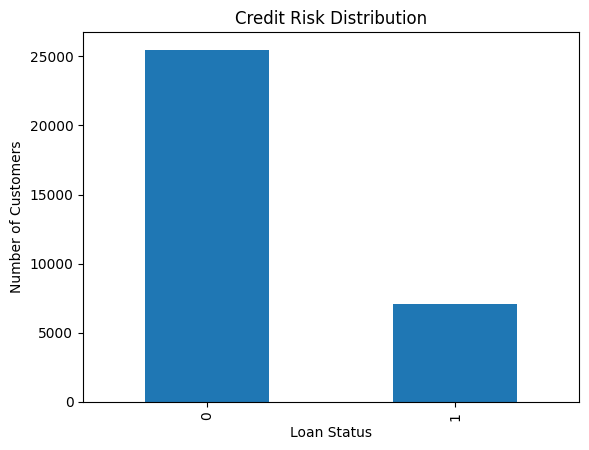

In [ ]:
import matplotlib.pyplot as plt

df["loan_status"].value_counts().plot(kind="bar")

plt.title("Credit Risk Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Customers")
plt.show()

Graph 2 — Income Distribution

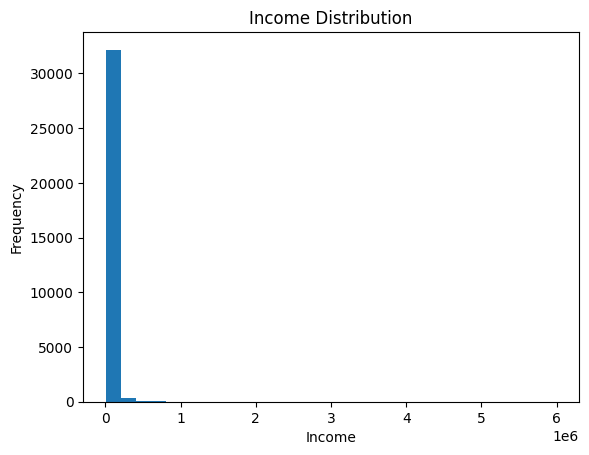

In [ ]:
plt.hist(df["person_income"], bins=30)

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

Graph 3 — Loan Amount Distribution

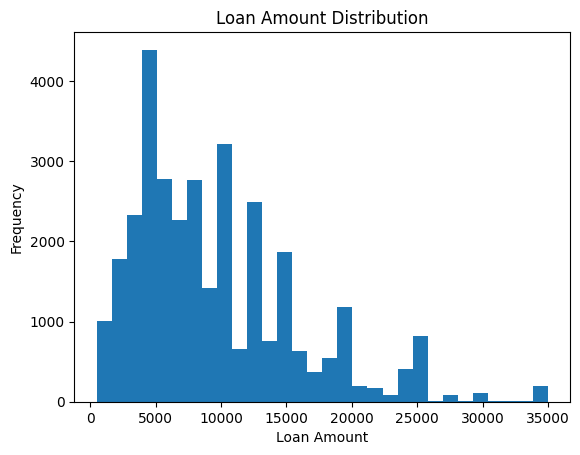

In [ ]:
plt.hist(df["loan_amnt"], bins=30)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

Graph 4 — Credit Risk vs Income

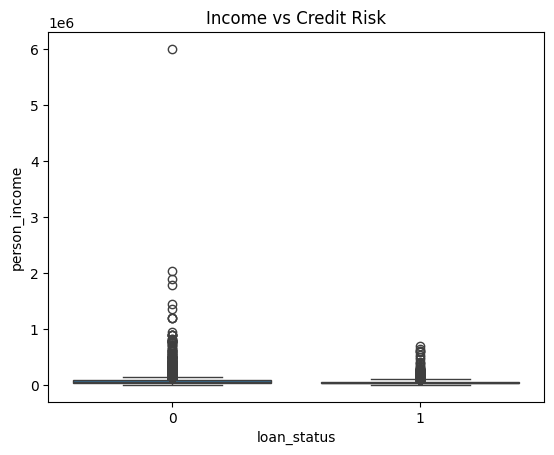

In [ ]:
import seaborn as sns

sns.boxplot(x="loan_status", y="person_income", data=df)

plt.title("Income vs Credit Risk")
plt.show()

Graph 5 — Correlation Heatmap

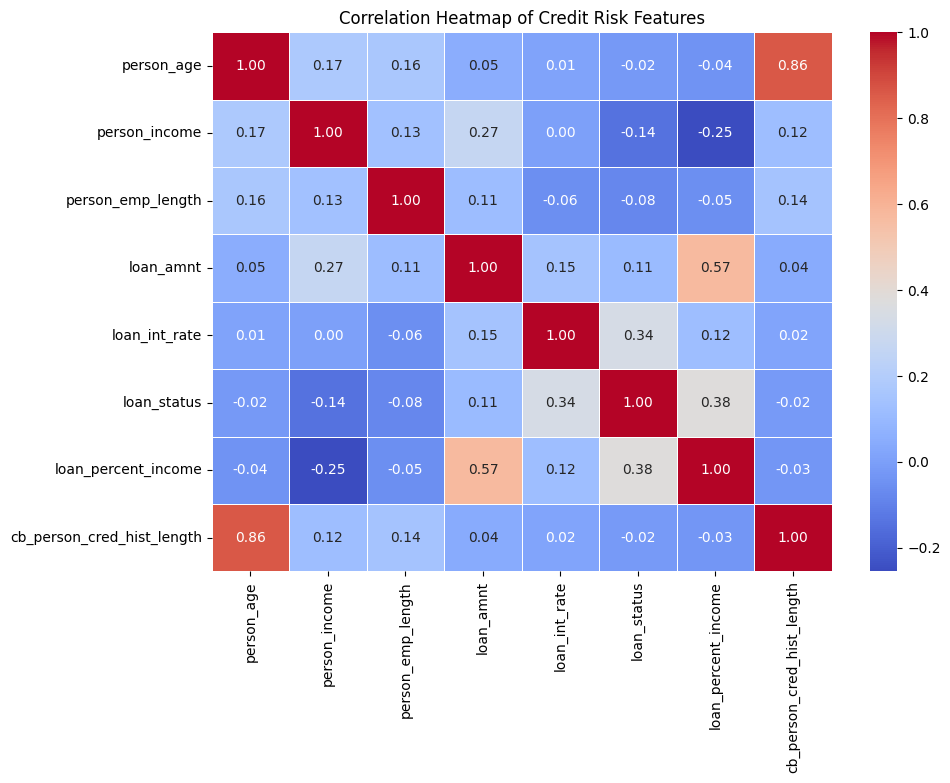

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
numeric_df = df.select_dtypes(include=["int64", "float64"])

# Calculate correlation
correlation = numeric_df.corr()

# Create heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Credit Risk Features")
plt.show()

STEP 5 — FEATURE ENGINEERING

Income-to-loan ratio

In [ ]:
df["income_loan_ratio"] = df["person_income"] / (df["loan_amnt"] + 1)
print(df)

       person_age  person_income person_home_ownership  person_emp_length  \
0              22          59000                  RENT              123.0   
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE                4.0   
32578          65          76000                  RENT                3.0   
32579          56         150000              MORTGAGE                5.0   
32580          66          42000                  RENT                2.0   

           loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \

STEP 6 data preprocessing

6.1 Separate features and target

In [ ]:
y = df["loan_status"]
print(y)

0        1
1        0
2        1
3        1
4        1
        ..
32576    0
32577    0
32578    1
32579    0
32580    0
Name: loan_status, Length: 32581, dtype: int64


Features are everything except loan_status:

In [ ]:
X = df.drop("loan_status", axis=1)
print(X)

       person_age  person_income person_home_ownership  person_emp_length  \
0              22          59000                  RENT              123.0   
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE                4.0   
32578          65          76000                  RENT                3.0   
32579          56         150000              MORTGAGE                5.0   
32580          66          42000                  RENT                2.0   

           loan_intent loan_grade  loan_amnt  loan_int_rate  \
0           

6.2 Identify numerical and categorical columns

In [ ]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical Features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


6.3 Create preprocessing pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='mean')),
                ('scaler', StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length'],
      dtype='object')),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object'))])

6.4 Check the preprocessed data

In [ ]:
X_processed = preprocessor.fit_transform(X)

print("Original shape:", X.shape)
print("Processed shape:", X_processed.shape)

Original shape: (32581, 12)
Processed shape: (32581, 26)


STEP 7 Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (26064, 12)
Testing data: (6517, 12)


Then preprocess:

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Processed training data: (26064, 26)
Processed testing data: (6517, 26)


STEP 8 — LOGISTIC REGRESSION

FIRST MODEL

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("credit_risk_dataset.csv")

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

num = X.select_dtypes(include=["int64","float64"]).columns
cat = X.select_dtypes(include=["object"]).columns

pre = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore")), cat)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_model = make_pipeline(pre, LogisticRegression(max_iter=1000))
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))

Logistic Regression Accuracy: 0.8671167715206384


STEP 9 DECISION TREE

Second model:

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("credit_risk_dataset.csv")

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

num = X.select_dtypes(include=["int64", "float64"]).columns
cat = X.select_dtypes(include=["object"]).columns

pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num),
    ("cat", make_pipeline(
        SimpleImputer(strategy="most_frequent"),
        OneHotEncoder(handle_unknown="ignore")
    ), cat)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tree_model = make_pipeline(
    pre,
    DecisionTreeClassifier(random_state=42)
)

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))

Decision Tree Accuracy: 0.8872180451127819


STEP 10 — RANDOM FOREST

Third model:

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("credit_risk_dataset.csv")

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

num = X.select_dtypes(include=["int64", "float64"]).columns
cat = X.select_dtypes(include=["object"]).columns

pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num),
    ("cat", make_pipeline(
        SimpleImputer(strategy="most_frequent"),
        OneHotEncoder(handle_unknown="ignore")
    ), cat)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = make_pipeline(
    pre,
    RandomForestClassifier(n_estimators=100, random_state=42)
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9338652754334816


STEP 11 — MODEL EVALUATION

Precision, Recall, F1-Score and ROC-AUC.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

STEP 12 — CONFUSION MATRIX

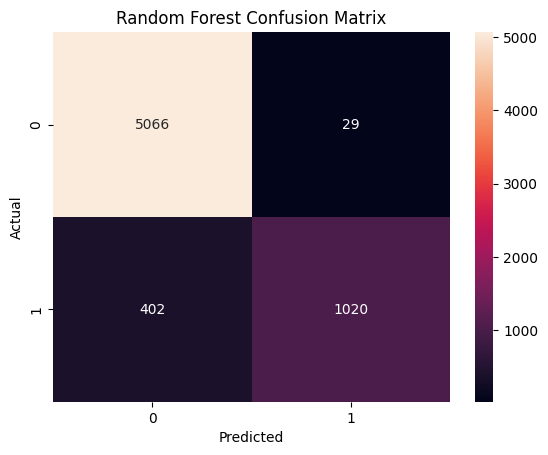

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

STEP 13 — ROC Curve

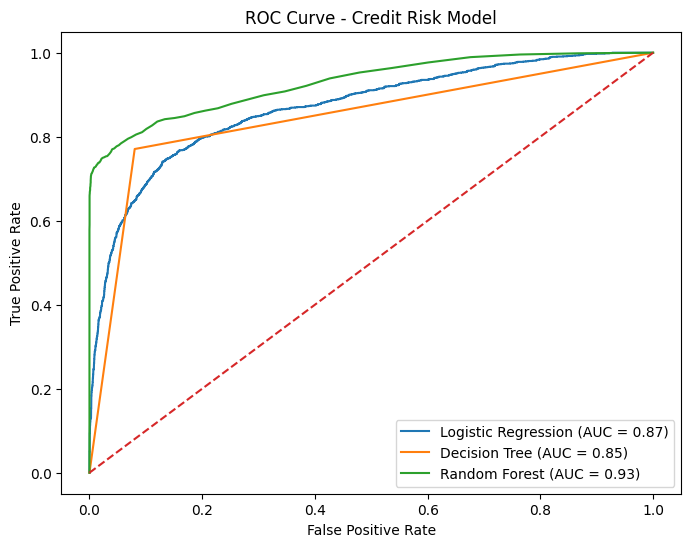

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": log_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=name + " (AUC = " + str(round(auc, 2)) + ")")

plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Credit Risk Model")
plt.legend()
plt.show()

STEP 14 — Select the Best Model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    pred = model.predict(X_test)
    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.867117   0.766795  0.561885  0.648539
1        Decision Tree  0.887218   0.728239  0.770745  0.748890
2        Random Forest  0.933865   0.972355  0.717300  0.825577


STEP 15 — Model Evaluation

In [ ]:
from sklearn.metrics import classification_report

for name, model in models.items():
    pred = model.predict(X_test)
    print("\n", name)
    print(classification_report(y_test, pred))


 Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5095
           1       0.77      0.56      0.65      1422

    accuracy                           0.87      6517
   macro avg       0.83      0.76      0.78      6517
weighted avg       0.86      0.87      0.86      6517


 Decision Tree
              precision    recall  f1-score   support

           0       0.93      0.92      0.93      5095
           1       0.73      0.77      0.75      1422

    accuracy                           0.89      6517
   macro avg       0.83      0.85      0.84      6517
weighted avg       0.89      0.89      0.89      6517


 Random Forest
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5095
           1       0.97      0.72      0.83      1422

    accuracy                           0.93      6517
   macro avg       0.95      0.86      0.89      6517
weighted avg       0

STEP 16 — Model Comparison

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for name, model in models.items():
    pred = model.predict(X_test)

    print(
        name,
        " | Accuracy:", round(accuracy_score(y_test, pred), 3),
        " | Precision:", round(precision_score(y_test, pred), 3),
        " | Recall:", round(recall_score(y_test, pred), 3),
        " | F1:", round(f1_score(y_test, pred), 3)
    )

Logistic Regression  | Accuracy: 0.867  | Precision: 0.767  | Recall: 0.562  | F1: 0.649
Decision Tree  | Accuracy: 0.887  | Precision: 0.728  | Recall: 0.771  | F1: 0.749
Random Forest  | Accuracy: 0.934  | Precision: 0.972  | Recall: 0.717  | F1: 0.826


STEP 17 — Final Credit Risk Prediction

In [ ]:
final_model = rf_model

prediction = final_model.predict(X_test.iloc[[0]])

if prediction[0] == 1:
    print("Credit Risk: High")
else:
    print("Credit Risk: Low")

Credit Risk: Low
